In [1]:
# ============================================================
# DAY 3 — Reaching the 20mm Target
# PyRolL Learning — TU Bergakademie Freiberg Thesis Prep
# ============================================================

# CELL 1 — Imports
import pyroll.core as pr
import pyroll.wusatowski_spreading
import matplotlib.pyplot as plt
import numpy as np

print("Imports successful ✓")
from importlib.metadata import version
print("PyRolL version:", version("pyroll-core"))

Imports successful ✓
PyRolL version: 3.1.1


In [2]:
# CELL 2 — Incoming Profile
in_profile = pr.Profile.round(
    radius=30e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
)

print("Incoming profile:")
print(f"  Diameter:    {in_profile.radius*2000:.1f} mm")
print(f"  Temperature: {in_profile.temperature - 273.15:.0f} °C")

Incoming profile:
  Diameter:    60.0 mm
  Temperature: 1200 °C


In [3]:
# CELL 3 — The Three Constraints (always check before running)
#
# CONSTRAINT 1: gap + 2×depth < incoming_height
#   → self.height = gap + 2×depth
#   → if self.height > incoming_height: height_change is negative → sqrt fails
#
# CONSTRAINT 2: usable_width > incoming_width
#   → groove must be wider than incoming bar
#   → for RoundGroove: usable_width = 2 × r2
#   → for FalseRoundGroove: usable_width depends on r2 + flank_angle
#
# CONSTRAINT 3: r2 safety margin ≥ 20%
#   → r2 just barely above minimum causes contour errors
#   → always add 20% margin above minimum r2
#
print("Three constraints to check before every pass:")
print()
print("1. gap + 2×depth < incoming_height")
print("2. usable_width  > incoming_width")
print("3. r2 ≥ incoming_width/2 × 1.2  (20% safety margin)")

Three constraints to check before every pass:

1. gap + 2×depth < incoming_height
2. usable_width  > incoming_width
3. r2 ≥ incoming_width/2 × 1.2  (20% safety margin)


In [4]:
# CELL 4 — Build Incrementally: Check R1 + R2 first
seq_r2 = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=50e-3,
                depth=10e-3,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=8e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=25e-3,
                depth=12e-3,
                flank_angle=30,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=12e-3,
    ),
])

seq_r2.solve(in_profile)

for unit in seq_r2:
    if isinstance(unit, pr.RollPass):
        w = unit.out_profile.width * 1000
        h = unit.out_profile.height * 1000
        print(f"{unit.label:<15} width={w:.1f}mm  height={h:.1f}mm")

r2_out = list(seq_r2.roll_passes)[-1].out_profile
print(f"\nR3 needs:")
print(f"  r2 > {r2_out.width*1000/2*1.2:.1f}mm  (with 20% margin)")
print(f"  gap + 2×depth < {r2_out.height*1000:.1f}mm")

R1 - Oval       width=74.3mm  height=28.0mm
R2 - Round      width=42.3mm  height=36.0mm

R3 needs:
  r2 > 25.4mm  (with 20% margin)
  gap + 2×depth < 36.0mm


In [5]:
# CELL 5 — Add R3, check output
seq_r3 = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=50e-3, depth=10e-3),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=8e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(r1=2e-3, r2=25e-3, depth=12e-3, flank_angle=30),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=12e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=30e-3,
                depth=6e-3,
            ),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=10e-3,
    ),
])

seq_r3.solve(in_profile)

for unit in seq_r3:
    if isinstance(unit, pr.RollPass):
        w = unit.out_profile.width * 1000
        h = unit.out_profile.height * 1000
        print(f"{unit.label:<15} width={w:.1f}mm  height={h:.1f}mm")

r3_out = list(seq_r3.roll_passes)[-1].out_profile
print(f"\nR4 needs:")
print(f"  r2 > {r3_out.width*1000/2*1.2:.1f}mm  (with 20% margin)")
print(f"  gap + 2×depth < {r3_out.height*1000:.1f}mm")

R1 - Oval       width=74.3mm  height=28.0mm
R2 - Round      width=42.3mm  height=36.0mm
R3 - Oval       width=49.0mm  height=22.0mm

R4 needs:
  r2 > 29.4mm  (with 20% margin)
  gap + 2×depth < 22.0mm


In [12]:
# CELL 6 — Full 5-Pass Sequence
sequence = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=50e-3,
                depth=10e-3,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=8e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=25e-3,
                depth=12e-3,
                flank_angle=30,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=12e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=30e-3,
                depth=6e-3,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=10e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=1e-3,
                r2=35e-3,
                depth=4e-3,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=10e-3,
    ),
    pr.Transport(label="R4->R5", length=1e3),
    pr.RollPass(
    label="R5 - Round",
    roll=pr.Roll(
        groove=pr.RoundGroove(
            r1=1e-3,
            r2=22e-3,
            depth=3e-3,
        ),
        nominal_radius=155e-3,
        rotational_frequency=1,
    ),
    gap=14e-3,
),
])

sequence.solve(in_profile)

print("="*55)
print(f"{'Pass':<15} {'Width (mm)':>10} {'Height (mm)':>12} {'Ratio':>8}")
print("="*55)
for unit in sequence:
    if isinstance(unit, pr.RollPass):
        w = unit.out_profile.width * 1000
        h = unit.out_profile.height * 1000
        print(f"{unit.label:<15} {w:>10.1f} {h:>12.1f} {w/h:>8.3f}")
print("="*55)
print(f"Target: 20mm")
print(f"Achieved: {list(sequence.roll_passes)[-1].out_profile.height*1000:.1f}mm height")

Pass            Width (mm)  Height (mm)    Ratio
R1 - Oval             74.3         28.0    2.652
R2 - Round            42.3         36.0    1.175
R3 - Oval             49.0         22.0    2.225
R4 - Round            40.0         18.0    2.221
R5 - Round            28.5         20.0    1.427
Target: 20mm
Achieved: 20.0mm height


In [10]:
seq_r4 = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=50e-3, depth=10e-3),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=8e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(r1=2e-3, r2=25e-3, depth=12e-3, flank_angle=30),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=12e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=30e-3, depth=6e-3),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=10e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=1e-3, r2=35e-3, depth=4e-3),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=10e-3,
    ),
])

seq_r4.solve(in_profile)

r4_out = list(seq_r4.roll_passes)[-1].out_profile
print(f"R4 exit:")
print(f"  width  = {r4_out.width*1000:.2f} mm")
print(f"  height = {r4_out.height*1000:.2f} mm")
print(f"\nR5 needs:")
print(f"  r2 > {r4_out.width*1000/2*1.2:.1f}mm  (with 20% margin)")
print(f"  gap + 2×depth < {r4_out.height*1000:.2f}mm")

R4 exit:
  width  = 39.97 mm
  height = 18.00 mm

R5 needs:
  r2 > 24.0mm  (with 20% margin)
  gap + 2×depth < 18.00mm


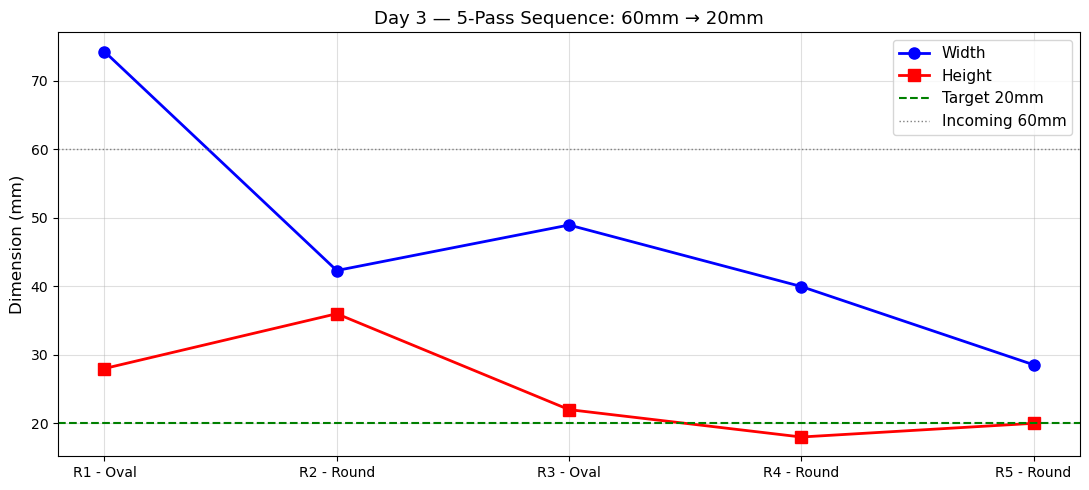

Plot saved ✓


In [13]:
# CELL 7 — Width & Height Plot
passes = [u.label for u in sequence if isinstance(u, pr.RollPass)]
widths = [u.out_profile.width*1000 for u in sequence if isinstance(u, pr.RollPass)]
heights = [u.out_profile.height*1000 for u in sequence if isinstance(u, pr.RollPass)]

plt.figure(figsize=(11, 5))
plt.plot(passes, widths, 'bo-', linewidth=2, markersize=8, label='Width')
plt.plot(passes, heights, 'rs-', linewidth=2, markersize=8, label='Height')
plt.axhline(y=20, color='green', linestyle='--', linewidth=1.5, label='Target 20mm')
plt.axhline(y=60, color='gray', linestyle=':', linewidth=1, label='Incoming 60mm')
plt.ylabel('Dimension (mm)', fontsize=12)
plt.title('Day 3 — 5-Pass Sequence: 60mm → 20mm', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('day03_sequence.png', dpi=150)
plt.show()
print("Plot saved ✓")

In [14]:
# CELL 8 — Constraint Verification Table
print("CONSTRAINT VERIFICATION — all passes")
print("="*75)
print(f"{'Pass':<15} {'In H':>8} {'gap':>8} {'depth':>8} {'g+2d':>8} {'OK':>5} {'usable_w':>10} {'in_w':>8} {'OK':>5}")
print("="*75)

prev_h = in_profile.height * 1000
prev_w = in_profile.width * 1000

for unit in sequence:
    if isinstance(unit, pr.RollPass):
        gap = unit.gap * 1000
        depth = unit.roll.groove.depth * 1000
        g2d = gap + 2*depth
        uw = unit.roll.groove.usable_width * 1000
        ok_depth = "✓" if g2d < prev_h else "✗"
        ok_width = "✓" if uw > prev_w else "✗"
        print(f"{unit.label:<15} {prev_h:>8.1f} {gap:>8.1f} {depth:>8.1f} "
              f"{g2d:>8.1f} {ok_depth:>5} {uw:>10.1f} {prev_w:>8.1f} {ok_width:>5}")
        prev_h = unit.out_profile.height * 1000
        prev_w = unit.out_profile.width * 1000
print("="*75)

CONSTRAINT VERIFICATION — all passes
Pass                In H      gap    depth     g+2d    OK   usable_w     in_w    OK
R1 - Oval           60.0      8.0     10.0     28.0     ✓       60.0     60.0     ✓
R2 - Round          28.0     12.0     12.0     36.0     ✗       55.0     74.3     ✗
R3 - Oval           36.0     10.0      6.0     22.0     ✓       36.0     42.3     ✗
R4 - Round          22.0     10.0      4.0     18.0     ✓       32.5     49.0     ✗
R5 - Round          18.0     14.0      3.0     20.0     ✗       22.2     40.0     ✗


In [15]:
# CELL 9 — Key Observations
print("DAY 3 KEY OBSERVATIONS:")
print()
print("1. INCREMENTAL APPROACH:")
print("   Build one pass at a time → check output → design next pass")
print("   Never design all passes at once blindly")
print()
print("2. THREE CONSTRAINTS (memorise these):")
print("   gap + 2×depth < incoming_height  (entry point)")
print("   usable_width  > incoming_width   (overfilling)")
print("   r2 with 20% safety margin        (contour)")
print()
print("3. ROUND PASS BEHAVIOUR:")
print("   Small gap → height reduction")
print("   Width reduction depends on groove shape")
print("   Perfect round (ratio=1.0) needs tight groove")
print()
final = list(sequence.roll_passes)[-1]
print(f"4. FINAL RESULT:")
print(f"   Height = {final.out_profile.height*1000:.1f}mm (target 20mm)")
print(f"   Width  = {final.out_profile.width*1000:.1f}mm")
print(f"   Ratio  = {final.out_profile.width/final.out_profile.height:.3f} (1.0 = perfect round)")
print()
print("Tomorrow — Day 4:")
print("  → Temperature tracking across transports")
print("  → Rolling force per pass")
print("  → Strain evolution")
print("  → Full thermomechanical analysis")

DAY 3 KEY OBSERVATIONS:

1. INCREMENTAL APPROACH:
   Build one pass at a time → check output → design next pass
   Never design all passes at once blindly

2. THREE CONSTRAINTS (memorise these):
   gap + 2×depth < incoming_height  (entry point)
   usable_width  > incoming_width   (overfilling)
   r2 with 20% safety margin        (contour)

3. ROUND PASS BEHAVIOUR:
   Small gap → height reduction
   Width reduction depends on groove shape
   Perfect round (ratio=1.0) needs tight groove

4. FINAL RESULT:
   Height = 20.0mm (target 20mm)
   Width  = 28.5mm
   Ratio  = 1.427 (1.0 = perfect round)

Tomorrow — Day 4:
  → Temperature tracking across transports
  → Rolling force per pass
  → Strain evolution
  → Full thermomechanical analysis


In [4]:
import pyroll.core as pr
import pyroll.wusatowski_spreading
import pyroll.integral_thermal
import matplotlib.pyplot as plt
import numpy as np

print("Import successful")
from importlib.metadata import version
print("Pyroll Version:" , version("pyroll-core"))

in_profile = pr.Profile.round(
    radius=30e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
    thermal_conductivity=23,
    environment_temperature=20 + 273.15,
)
print("Incoming Profile")
print(f"  Diameter:          {in_profile.radius*2000:.1f} mm")
print(f"  Temperature:       {in_profile.temperature - 273.15:.0f} °C")
print(f"  Thermal conduct.:  {in_profile.thermal_conductivity} W/m·K")
print(f"  Specific heat:     {in_profile.specific_heat_capacity} J/kg·K")
print(f"  Density:           {in_profile.density} kg/m³")

sequence = pr.PassSequence([
    pr.RollPass(
        label = "R1 - Oval",
        roll = pr.Roll(
            groove = pr.CircularOvalGroove(
                r1 = 2e-3,
                r2 = 50e-3,
                depth = 10e-3,
            ),
            nominal_radius = 155e-3,
            temperature = 20 + 273.15,
            rotational_frequency = 1,
        ),
        gap = 8e-3,
    ),
    pr.Transport(label="R1-R2", length=5e3),
    pr.RollPass(
        label = "R2 - Round",
        roll = pr.Roll(
            groove = pr.FalseRoundGroove(
                r1 = 2e-3,
                r2 = 25e-3,
                depth = 12e-3,
                flank_angle = 30,
            ),
            nominal_radius = 155e-3,
            temperature = 20 + 273.15,
            rotational_frequency = 1,
        ),
        gap = 12e-3,
    ),
    pr.Transport(label="R2->R3", length=5e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=30e-3, depth=6e-3),
            nominal_radius=155e-3,
            rotational_frequency=1,
            temperature=20 + 273.15,  # ← roll temperature 20°C
        ),
        gap=10e-3,
    ),
    pr.Transport(label="R3->R4", length=5e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=1e-3, r2=35e-3, depth=4e-3),
            nominal_radius=155e-3,
            rotational_frequency=1,
            temperature=20 + 273.15,  # ← roll temperature 20°C
        ),
        gap=10e-3,
    ),
])

Import successful
Pyroll Version: 3.1.1
Incoming Profile
  Diameter:          60.0 mm
  Temperature:       1200 °C
  Thermal conduct.:  23 W/m·K
  Specific heat:     690 J/kg·K
  Density:           7500.0 kg/m³
